In [ ]:
import numpy as np
import statsmodels.api as sm


import matplotlib.pyplot as plt
import matplotlib as mp
import pandas as pd

from google.colab import drive

In [ ]:
# Mount Drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
# Read CSV
df = pd.read_csv('/content/drive/MyDrive/Astley equation paper/mass-length-scaling.csv')
df.head()

,Snake ID,Dataset,Location,Location ID,SVL (cm),Mass (g),Species,Status
0,2018DP01,Current,Northern Queensland,1,113.988000,185.1,D. punctulatus,Wild-caught
1,2018DP02,Current,Northern Queensland,1,127.443333,267.2,D. punctulatus,Wild-caught
2,2018DP03,Current,Northern Queensland,1,88.973333,84.8,D. punctulatus,Wild-caught
3,2018DC04,Current,Northern Queensland,1,77.373000,47.7,D. calligastra,Wild-caught
4,2018DC05,Current,Northern Queensland,1,84.258333,85.5,D. calligastra,Wild-caught


# Graphs!
Mass (g) vs SVL (cm) for all snakes included in analysis

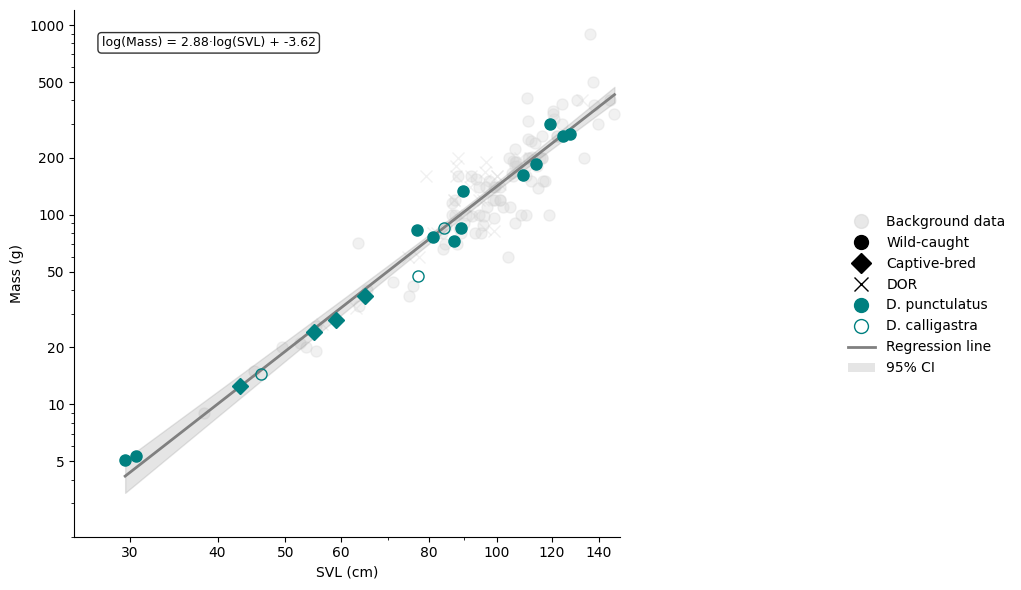

In [ ]:
# Plot
masses = df['Mass (g)']
log_mass = np.log10(masses)

svls = df['SVL (cm)']
log_svl = np.log10(svls)

fig, ax = plt.subplots(figsize=(8, 6)) # Adjusted figure size for a single panel

# Set logarithmic scales on axes
ax.set_xscale('log')
ax.set_yscale('log')

# Define custom tick locations for x-axis (SVL in cm)
x_ticks = [30, 40, 50, 60, 80, 100, 120, 140]
ax.set_xticks(x_ticks)
ax.set_xlim(25, 150) # Set reasonable limits for x-axis

# Define custom tick locations for y-axis (Mass in g)
y_ticks = [5, 10, 20, 50, 100, 200, 500, 1000]
ax.set_yticks(y_ticks)
ax.set_ylim(2, 1200) # Set reasonable limits for y-axis

# Format tick labels to show original values (not log values)
ax.get_xaxis().set_major_formatter(mp.ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(mp.ticker.ScalarFormatter())

# Set axis labels
ax.set_ylabel('Mass (g)')
ax.set_xlabel('SVL (cm)')

# Set a clean white background
ax.set_facecolor('white')
fig.set_facecolor('white')
ax.spines['top'].set_visible(False) # Remove top spine
ax.spines['right'].set_visible(False) # Remove right spine

# Remove grid lines
ax.grid(False)

# Define colors for plotting
DARK_TEAL = '#008080' # Single dark teal color for focal specimens
LIGHT_GREY = '#D3D3D3' # For background literature points
MEDIUM_GREY = 'grey' # For regression line

# Plotting individual points
for i in np.arange(len(df)):
    locID = df['Location ID'][i]
    stat = df['Status'][i]
    spec = df['Species'][i]

    # Determine marker shape based on Status
    shape_marker = 'o' # Default for Wild-caught
    if stat == "Captive-bred":
        shape_marker = 'D' # Diamond
    elif stat == "DOR":
        shape_marker = 'x'

    # Determine color and fill based on Location ID and Species
    if locID >= 4: # Background literature points
        mfc_color = LIGHT_GREY
        mec_color = LIGHT_GREY
        alpha_val = 0.3
        zorder_val = 1
    else: # Focal specimens
        mec_color = DARK_TEAL
        alpha_val = 1
        zorder_val = 3
        if spec == "D. punctulatus":
            mfc_color = DARK_TEAL
        else: # D. calligastra
            mfc_color = 'none' # Open symbol

    # Plot on log-scaled axes by passing original values
    ax.plot(svls[i], masses[i], marker=shape_marker, mfc=mfc_color, mec=mec_color,
            alpha=alpha_val, ms=8, zorder=zorder_val, linestyle='None')


# Regression line and CI
# Remove rows with NaN values in log_svl or log_mass for regression
mask = ~np.isnan(log_svl) & ~np.isnan(log_mass)
x_log_for_model = log_svl[mask]
y_log_for_model = log_mass[mask]

# Fit the model
model = sm.OLS(y_log_for_model, sm.add_constant(x_log_for_model)).fit()

# Get the 95% confidence intervals for the regression line
# Ensure sorted x values for fill_between
sort_idx = np.argsort(x_log_for_model)
x_log_sorted = x_log_for_model.iloc[sort_idx]
x_const_sorted = sm.add_constant(x_log_sorted)
predictions = model.get_prediction(x_const_sorted)
confidence_intervals = predictions.conf_int(alpha=0.05)

# Plot regression line and CI on log-scaled axes.
# Convert log-transformed values back to original scale for plotting on log-log axes
ax.plot(10**x_log_sorted, 10**model.predict(x_const_sorted), color=MEDIUM_GREY, label='Regression line', zorder=2, lw=2)
ax.fill_between(10**x_log_sorted, 10**confidence_intervals[:, 0], 10**confidence_intervals[:, 1],
                   color=MEDIUM_GREY, alpha=0.2, label='95% CI', zorder=2)


# Manual legend creation for Type (Status) and Species
lms = 10 # legend marker size

legend_elements = []

# Background data entry
legend_elements.append(mp.lines.Line2D([0],[0], marker='o', color='k', mfc=LIGHT_GREY, mec=LIGHT_GREY, label="Background data", ms=lms, alpha=0.5, linestyle='None'))

# Status (Type) Legend entries - showing marker shapes in generic black
legend_elements.append(mp.lines.Line2D([0],[0], marker='o', color='k', mfc='k', mec='k', label="Wild-caught", ms=lms, linestyle='None'))
legend_elements.append(mp.lines.Line2D([0],[0], marker='D', color='k', mfc='k', mec='k', label="Captive-bred", ms=lms, linestyle='None'))
legend_elements.append(mp.lines.Line2D([0],[0], marker='x', color='k', mfc='k', mec='k', label="DOR", ms=lms, linestyle='None'))

# Species Legend entries - showing dark teal color and fill style
legend_elements.append(mp.lines.Line2D([0],[0], marker='o', color='k', mfc=DARK_TEAL, mec=DARK_TEAL, label="D. punctulatus", ms=lms, linestyle='None'))
legend_elements.append(mp.lines.Line2D([0],[0], marker='o', color='k', mfc='none', mec=DARK_TEAL, label="D. calligastra", ms=lms, linestyle='None'))

# Regression Line and CI legend entries
legend_elements.append(mp.lines.Line2D([0],[0], color=MEDIUM_GREY, label='Regression line', linestyle='-', lw=2))
legend_elements.append(mp.patches.Patch(facecolor=MEDIUM_GREY, alpha=0.2, label='95% CI'))


# Place the legend outside the plot area
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=1, frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0, 0.8, 1]) # Adjust layout to make space for the legend on the right

# Equation text
slope = model.params['SVL (cm)']
intercept = model.params['const']

eq_text = f"log(Mass) = {slope:.2f}·log(SVL) + {intercept:.2f}"
ax.text(0.05, 0.95, eq_text, transform=ax.transAxes,
           verticalalignment='top', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

In [ ]:
from google.colab import files

fig.savefig('scaling_graph2.pdf')
files.download('scaling_graph2.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>